<a href="https://colab.research.google.com/github/Markwema86/Portfolio-Analysis-Engine/blob/main/Portfolio_Analysis_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Answering
#### Describing the past. What happened, how stocks moved, how risky they were.

In [37]:
# install the library
!pip install yfinance

In [38]:
# pull real data
import yfinance as yf
import pandas as pd

# These are real stock tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Download 3 years of daily closing prices
data = yf.download(tickers, start='2023-01-01', end='2026-01-01')['Close']

print(data.head())
print(data.shape)

/tmp/ipykernel_9209/3444076366.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2023-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

Ticker            AAPL       AMZN      GOOGL        MSFT        TSLA
Date                                                                
2023-01-03  122.982704  85.820000  88.389458  233.452805  108.099998
2023-01-04  124.251198  85.139999  87.357994  223.240829  113.639999
2023-01-05  122.933548  83.120003  85.493393  216.624481  110.339996
2023-01-06  127.456787  86.080002  86.624054  219.177460  113.059998
2023-01-09  127.977943  87.360001  87.298470  221.311447  119.769997
(752, 5)


**What's happening:** hitting Yahoo Finance's servers and pulling a full 3 year of real closing prices for 5 companies - the same data professional analysts use.

 Exploring The Real Mess

In [39]:
# Any missing trading days?
print(data.isnull().sum())

Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
TSLA     0
dtype: int64


In [40]:
# Basic stats on real prices
print(data.describe())

Ticker        AAPL        AMZN       GOOGL        MSFT        TSLA
count   752.000000  752.000000  752.000000  752.000000  752.000000
mean    202.342273  174.584881  163.619381  394.701784  268.253285
std      34.337950   43.718781   49.670777   75.412357   88.567771
min     122.933548   83.120003   85.493393  216.624481  108.099998
25%     175.687019  135.480003  131.329559  330.945091  197.417500
50%     197.476570  182.070000  160.600410  406.346390  248.449997
75%     226.608330  213.615005  179.719727  441.165184  328.492493
max     285.659271  254.000000  323.001190  539.825195  489.880005


In [41]:
# What does the raw data look like?
print(data.tail(10))

Ticker            AAPL        AMZN       GOOGL        MSFT        TSLA
Date                                                                  
2025-12-17  271.335876  221.270004  296.511261  475.035736  467.260010
2025-12-18  271.685242  226.759995  302.247223  482.877869  483.369995
2025-12-19  273.162506  227.350006  306.943939  484.813446  481.200012
2025-12-22  270.467499  228.429993  309.562073  483.815735  488.730011
2025-12-23  271.854919  232.139999  314.128876  485.741333  485.559998
2025-12-24  273.302216  232.380005  313.869049  486.908630  485.399994
2025-12-26  272.893005  232.520004  313.289459  486.599365  475.190002
2025-12-29  273.252350  232.070007  313.339417  485.990753  459.640015
2025-12-30  272.573547  232.529999  313.629242  486.369904  454.429993
2025-12-31  271.355835  230.820007  312.779816  482.518677  449.720001


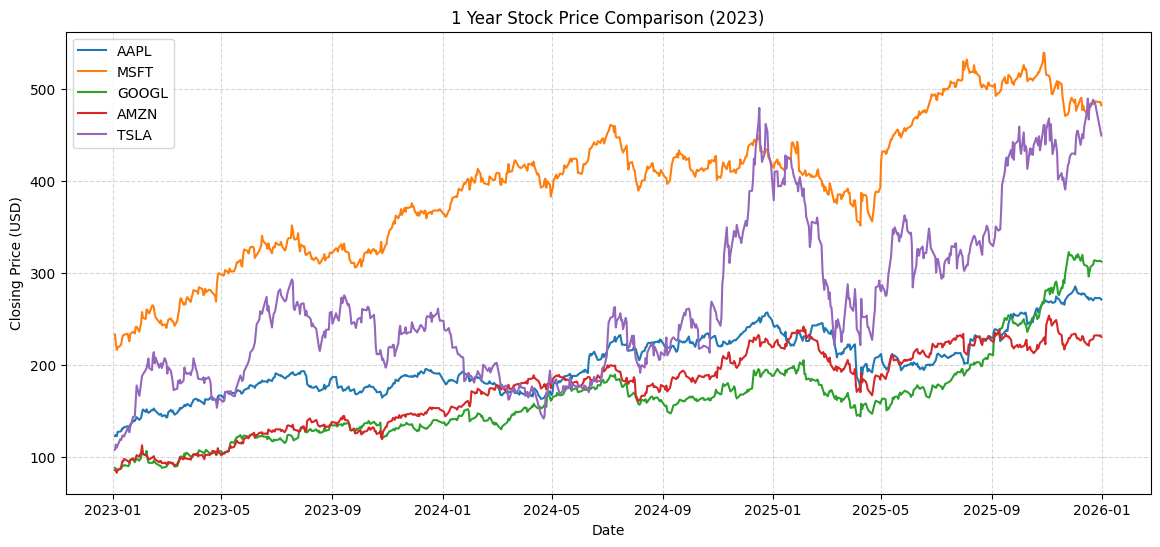

In [42]:
# Real Financial Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker)

plt.title('1 Year Stock Price Comparison (2023)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

The above is a multi-line time series chart - one of the most common charts in investment analysis.

#### One Key Finance Concept:Daily Returns

Stock price alone is misleading. A 3000 Amazon stock isn't "better" than a $170 Apple stock. What matters is how much it grows.

In [43]:
# Calculating daily percentage returns
returns = data.pct_change().dropna()

print(returns.head())

Ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
Date                                                        
2023-01-04  0.010314 -0.007924 -0.011670 -0.043743  0.051249
2023-01-05 -0.010605 -0.023726 -0.021344 -0.029638 -0.029039
2023-01-06  0.036794  0.035611  0.013225  0.011785  0.024651
2023-01-09  0.004089  0.014870  0.007786  0.009736  0.059349
2023-01-10  0.004456  0.028732  0.004545  0.007617 -0.007681


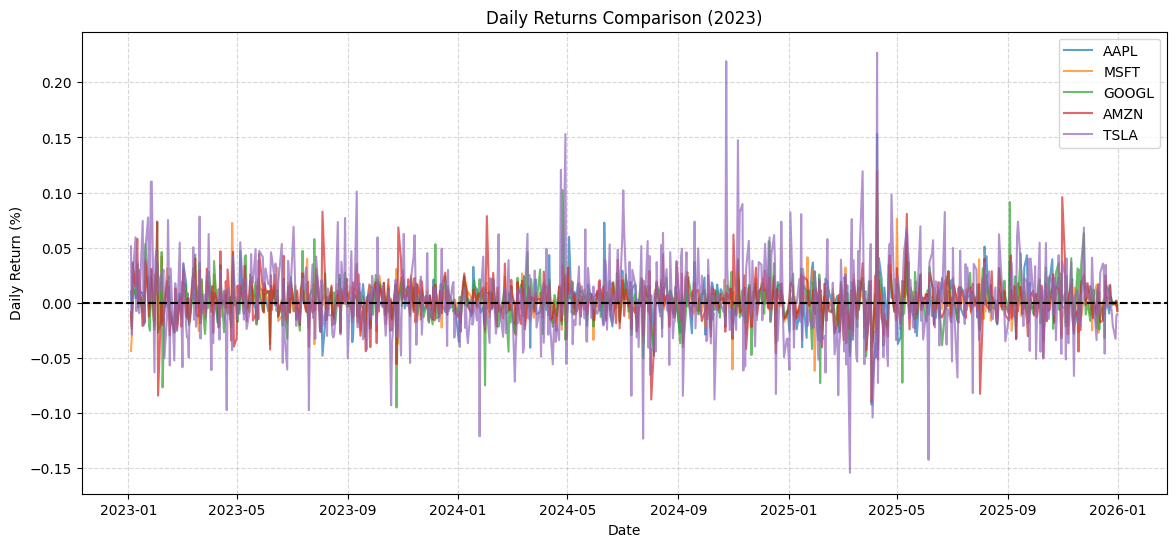

In [44]:
# Visualizing returns
plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(returns.index, returns[ticker], label=ticker, alpha=0.7)

plt.title('Daily Returns Comparison (2023)')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.legend()
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

What **pct_change()** does: Converts raw prices into percentage change day-over-day. This is how analysts actually compare stocks fairly - it's the foundation of portfolio analysis.

#### Measuring Volatility With Math
In finance, **volatility = standard deviation of daily returns**. The higher it is, the riskier the stock.

In [45]:
# Calculate annualized volatility for each stock
volatility = returns.std() * (252 ** 0.5)  # 252 = trading days in a year

print("Annualized Volatility:")
print(volatility.sort_values(ascending=False))

Annualized Volatility:
Ticker
TSLA     0.600591
AMZN     0.319368
GOOGL    0.302746
AAPL     0.256012
MSFT     0.232048
dtype: float64


What's happening:

- std() measures how wildly returns jump around
- We multiply by √252 to scale it to a full year - this is standard practice in finance

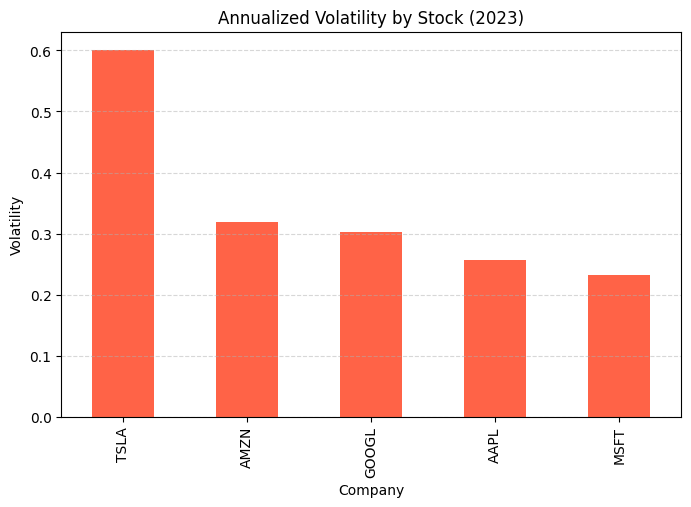

In [46]:
# Visualizing Volatility
plt.figure(figsize=(8, 5))
volatility.sort_values(ascending=False).plot(kind='bar', color='tomato')
plt.title('Annualized Volatility by Stock (2023)')
plt.xlabel('Company')
plt.ylabel('Volatility')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Comparing Risk vs Return
This is the most important chart in portfolio management. Every investment decision lives here.

In [47]:
# Average annual return
annual_return = returns.mean() * 252

# Build a comparison table
summary = pd.DataFrame({
    'Annual Return': annual_return,
    'Volatility (Risk)': volatility
})

print(summary.sort_values('Annual Return', ascending=False))

        Annual Return  Volatility (Risk)
Ticker                                  
TSLA         0.656810           0.600591
GOOGL        0.470087           0.302746
AMZN         0.382957           0.319368
AAPL         0.298152           0.256012
MSFT         0.270496           0.232048


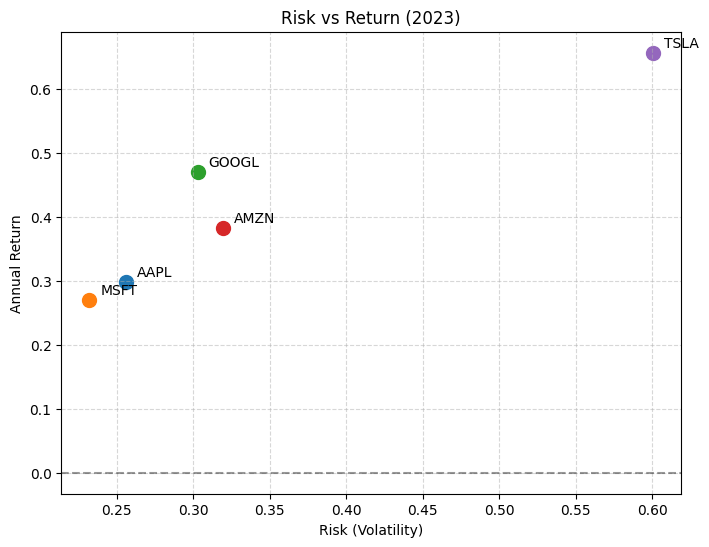

In [48]:
# Plot Risk vs Return - the core of portfolio theory
plt.figure(figsize=(8, 6))

for ticker in tickers:
    plt.scatter(
        summary.loc[ticker, 'Volatility (Risk)'],
        summary.loc[ticker, 'Annual Return'],
        s=100
    )
    plt.annotate(
        ticker,
        (summary.loc[ticker, 'Volatility (Risk)'],
        summary.loc[ticker, 'Annual Return']),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=10
    )

plt.title('Risk vs Return (2023)')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Annual Return')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4)
plt.grid(linestyle='--', alpha=0.5)
plt.show()

This scatter plot is the foundation of Modern Portfolio Theory - the framework every asset manager and portfolio manager uses. The idea is simple:

- Top left = ideal - high return, low risk
- Bottom right = worst - low return, high risk
- my job as a portfolio manager is to build a mix of assets that pushes your portfolio toward the top left

- Tesla was most volatile
- Tesla had the best return for its risk level
- Tesla landed on top right----and it wa not worth the risk

High return and high risk means Tesla rewards you, but could also hurt you badly in a bad year. That's not ideal for a wealth management portfolio where protecting client money matters as much as growing it.

### The Sharpe Ratio: One Number That Judges Every Stock
In portfolio management, we don't just ask **"did this stock make money?"** We ask **"did it make enough money for the risk it took?"**

That's exactly what the Sharpe Ratio measures:

**Sharpe Ratio = (Return - Risk Free Rate) / Volatility**

The risk free rate is what you'd earn doing nothing risky - like a US government bond. Currently around 5% (0.05).

In [49]:
risk_free_rate = 0.05

sharpe = (annual_return - risk_free_rate) / volatility

print("Sharpe Ratios:")
print(sharpe.sort_values(ascending=False))

Sharpe Ratios:
Ticker
GOOGL    1.387588
AMZN     1.042552
TSLA     1.010355
AAPL     0.969299
MSFT     0.950219
dtype: float64


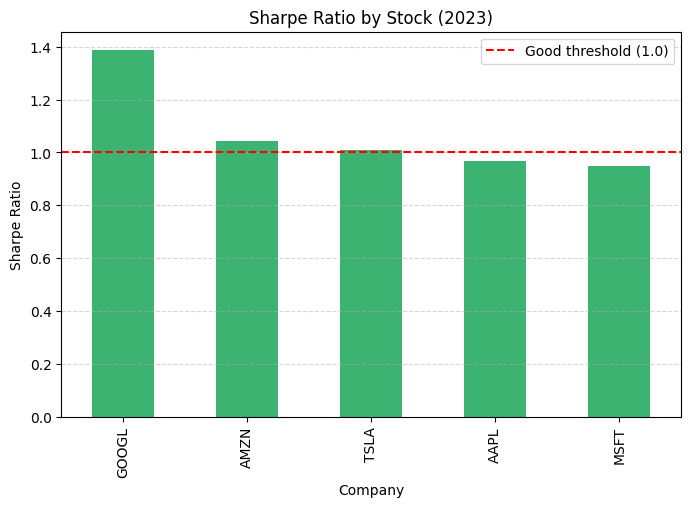

In [50]:
# Visualizing it
plt.figure(figsize=(8, 5))
sharpe.sort_values(ascending=False).plot(kind='bar', color='mediumseagreen')
plt.title('Sharpe Ratio by Stock (2023)')
plt.xlabel('Company')
plt.ylabel('Sharpe Ratio')
plt.axhline(y=1, color='red', linestyle='--', label='Good threshold (1.0)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

How to read sharpe ratio:

- Above 1.0 = good, earning well for the risk taken
- Below 1.0 = questionable, not enough return for the risk
- Negative = losing money after accounting for risk free rate

## Building a Mini Portfolio

Acting like an actual portfolio manager. I have a client. I need to split $100,000 across these 5 stocks.

In [51]:
# Defining portfolio weights (must add up to 1.0)
weights = {
    'AAPL': 0.30,
    'MSFT': 0.30,
    'GOOGL': 0.20,
    'AMZN': 0.10,
    'TSLA': 0.10   # Small Tesla allocation - high risk, so we limit exposure
}

weights_series = pd.Series(weights)

# Portfolio return
portfolio_return = (annual_return * weights_series).sum()

# Portfolio volatility (simplified)
portfolio_volatility = (volatility * weights_series).sum()

# Portfolio Sharpe
portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

print(f"Portfolio Annual Return:  {portfolio_return:.2%}")
print(f"Portfolio Volatility:     {portfolio_volatility:.2%}")
print(f"Portfolio Sharpe Ratio:   {portfolio_sharpe:.2f}")

Portfolio Annual Return:  36.86%
Portfolio Volatility:     29.90%
Portfolio Sharpe Ratio:   1.07


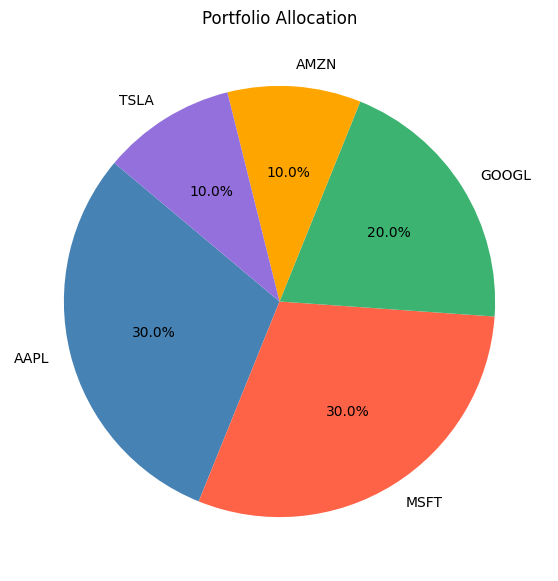

In [52]:
# Visualizing the allocation
plt.figure(figsize=(7, 7))
plt.pie(
    weights_series,
    labels=weights_series.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['steelblue','tomato','mediumseagreen','orange','mediumpurple']
)
plt.title('Portfolio Allocation')
plt.show()

What  I Just did

I just did in code what portfolio managers do in boardrooms:

- Measured each stock's risk and return
- Judged quality using the Sharpe Ratio
- Built a weighted portfolio that limits exposure to risky assets
- Visualized the allocation like a professional

I feel that the allocation is not right....But the rule in data science and finance:

**Never adjust a portfolio based on feeling. Adjust it based on evidence.**

So let's let the data tell us how to fix it.....by interrogating the Weights With Data

In [53]:
# First let's see exactly what each stock is contributing to the portfolio
# Contribution of each stock to overall return
contribution = annual_return * weights_series

print("Return Contribution per Stock:")
print(contribution.sort_values(ascending=False))

Return Contribution per Stock:
GOOGL    0.094017
AAPL     0.089446
MSFT     0.081149
TSLA     0.065681
AMZN     0.038296
dtype: float64


In [54]:
# Risk contribution per stock
risk_contribution = volatility * weights_series

print("\nRisk Contribution per Stock:")
print(risk_contribution.sort_values(ascending=False))


Risk Contribution per Stock:
AAPL     0.076804
MSFT     0.069614
GOOGL    0.060549
TSLA     0.060059
AMZN     0.031937
dtype: float64


In [55]:
# Side by side comparison
comparison = pd.DataFrame({
    'Weight': weights_series,
    'Annual Return': annual_return,
    'Volatility': volatility,
    'Sharpe Ratio': sharpe,
    'Return Contribution': contribution,
    'Risk Contribution': risk_contribution
})

print(comparison.round(3))

       Weight  Annual Return  Volatility  Sharpe Ratio  Return Contribution  \
AAPL      0.3          0.298       0.256         0.969                0.089   
AMZN      0.1          0.383       0.319         1.043                0.038   
GOOGL     0.2          0.470       0.303         1.388                0.094   
MSFT      0.3          0.270       0.232         0.950                0.081   
TSLA      0.1          0.657       0.601         1.010                0.066   

       Risk Contribution  
AAPL               0.077  
AMZN               0.032  
GOOGL              0.061  
MSFT               0.070  
TSLA               0.060  


Let **The Sharpe Ratio** Guide our Weights

The logic is simple - reward stocks with high Sharpe Ratios with more weight.

In [56]:
# Building smarter weights based on Sharpe Ratio
# Higher Sharpe = more allocation
sharpe_weights = sharpe / sharpe.sum()

print("Sharpe-Based Weights:")
print(sharpe_weights.sort_values(ascending=False).round(3))

Sharpe-Based Weights:
Ticker
GOOGL    0.259
AMZN     0.195
TSLA     0.188
AAPL     0.181
MSFT     0.177
dtype: float64


In [57]:
# Recalculating portfolio with smarter weights
smart_return = (annual_return * sharpe_weights).sum()
smart_volatility = (volatility * sharpe_weights).sum()
smart_sharpe = (smart_return - risk_free_rate) / smart_volatility

print(f"\nSmart Portfolio Annual Return:  {smart_return:.2%}")
print(f"Smart Portfolio Volatility:     {smart_volatility:.2%}")
print(f"Smart Portfolio Sharpe Ratio:   {smart_sharpe:.2f}")


Smart Portfolio Annual Return:  42.19%
Smart Portfolio Volatility:     34.11%
Smart Portfolio Sharpe Ratio:   1.09


Now lets compare Both Portfolios Head To Head

In [58]:
# Building comparison table
portfolio_comparison = pd.DataFrame({
    'Our Original Portfolio': [portfolio_return, portfolio_volatility, portfolio_sharpe],
    'Data-Driven Portfolio': [smart_return, smart_volatility, smart_sharpe]
}, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])

print(portfolio_comparison.round(3))

               Our Original Portfolio  Data-Driven Portfolio
Annual Return                   0.369                  0.422
Volatility                      0.299                  0.341
Sharpe Ratio                    1.066                  1.090


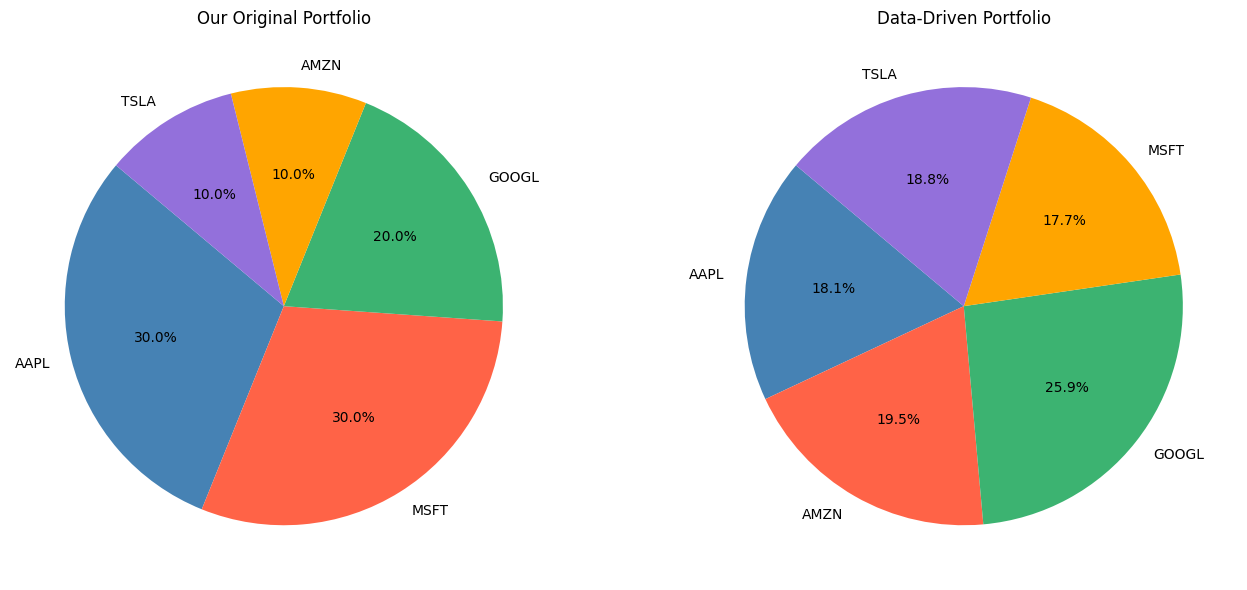

In [59]:
# Visualizing new allocation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original
axes[0].pie(
    weights_series,
    labels=weights_series.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['steelblue','tomato','mediumseagreen','orange','mediumpurple']
)
axes[0].set_title('Our Original Portfolio')

# Smart
axes[1].pie(
    sharpe_weights,
    labels=sharpe_weights.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['steelblue','tomato','mediumseagreen','orange','mediumpurple']
)
axes[1].set_title('Data-Driven Portfolio')

plt.tight_layout()
plt.show()

What we're doing above

This is called **portfolio optimization** - valuable skills in wealth and asset management.

Am not guessing weights anymore. Am deriving them mathematically from evidence.

Real portfolio managers do this exact process,..... with hundreds of assets and more complex models.

- Questions to ask myself

Which stock got the most weight in the data-driven portfolio - and does that make sense given its Sharpe?

**google.....yeah it makes sense since it has the highest sharpe ratio**

How much did Tesla's weight change?

**it went up with a 8.8%**

Did the Sharpe Ratio improve in the smart portfolio vs your original?

**yes it did...because it allocated more weights to stocks with higher sharpe ratio**

####⚠️ Problem
Past performance (is not = to) future results.

Tesla had a great 2023. But in 2022, it crashed over 65% in a single year. If we had used 2022 data, our model would have slashed Tesla's weight to almost zero.

 *the model is only as honest as the time period you feed it.


In [60]:
# Prove itt with data
# Let's check 2022 and see how dramatically the story changes
# Pulling 2022 data
data_2022 = yf.download(tickers, start='2022-01-01', end='2023-01-01')['Close']
returns_2022 = data_2022.pct_change().dropna()

annual_return_2022 = returns_2022.mean() * 252
volatility_2022 = returns_2022.std() * (252 ** 0.5)
sharpe_2022 = (annual_return_2022 - risk_free_rate) / volatility_2022

print("2022 Sharpe Ratios:")
print(sharpe_2022.sort_values(ascending=False).round(3))

/tmp/ipykernel_9209/3078998411.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_2022 = yf.download(tickers, start='2022-01-01', end='2023-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

2022 Sharpe Ratios:
Ticker
MSFT    -0.888
AAPL    -0.899
GOOGL   -1.228
AMZN    -1.271
TSLA    -1.561
dtype: float64


In [61]:
# Comparing Sharpe across both years side by side
sharpe_comparison = pd.DataFrame({
    '2022 Sharpe': sharpe_2022,
    '2023 Sharpe': sharpe
})

print("\nSharpe Ratio: 2022 vs 2023")
print(sharpe_comparison.round(3))


Sharpe Ratio: 2022 vs 2023
        2022 Sharpe  2023 Sharpe
Ticker                          
AAPL         -0.899        0.969
AMZN         -1.271        1.043
GOOGL        -1.228        1.388
MSFT         -0.888        0.950
TSLA         -1.561        1.010


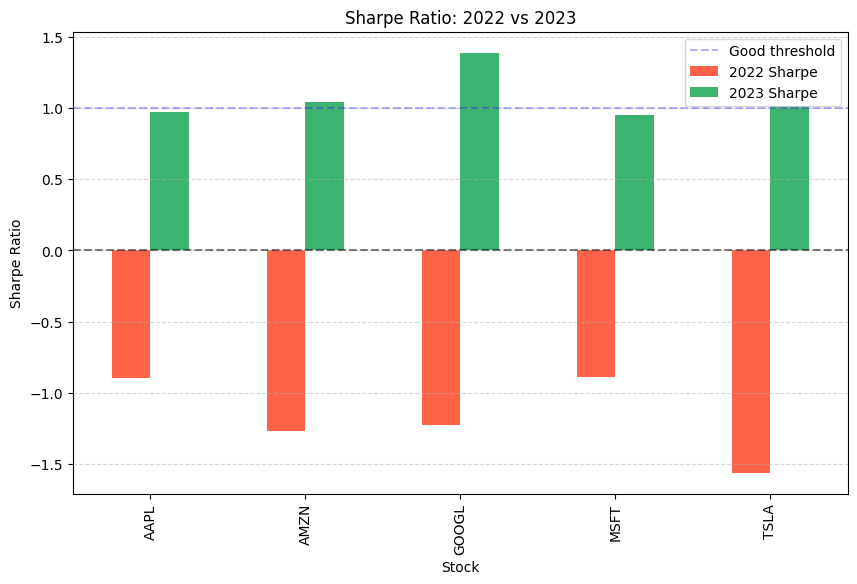

In [62]:
# Visualizing the difference
sharpe_comparison.plot(kind='bar', figsize=(10, 6), color=['tomato', 'mediumseagreen'])
plt.title('Sharpe Ratio: 2022 vs 2023')
plt.xlabel('Stock')
plt.ylabel('Sharpe Ratio')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='blue', linestyle='--', alpha=0.3, label='Good threshold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Build A More Honest Portfolio Using Both Years

A smarter approach - averaging the Sharpe across multiple years so one good or bad year doesn't dominate decision.

In [63]:
# Averaging Sharpe across 2022 and 2023
avg_sharpe = (sharpe_2022 + sharpe) / 2

print("Average Sharpe (2022-2023):")
print(avg_sharpe.sort_values(ascending=False).round(3))

Average Sharpe (2022-2023):
Ticker
GOOGL    0.080
AAPL     0.035
MSFT     0.031
AMZN    -0.114
TSLA    -0.275
dtype: float64


In [64]:
# Handling negative Sharpe values before weighting
# can't give negative weight to a stock - so floor at zero
avg_sharpe_clipped = avg_sharpe.clip(lower=0)

# If all are zero or negative, this catches that edge case
if avg_sharpe_clipped.sum() == 0:
    balanced_weights = pd.Series([1/len(tickers)]*len(tickers), index=tickers)
else:
    balanced_weights = avg_sharpe_clipped / avg_sharpe_clipped.sum()

print("\nBalanced Portfolio Weights:")
print(balanced_weights.sort_values(ascending=False).round(3))


Balanced Portfolio Weights:
Ticker
GOOGL    0.546
AAPL     0.242
MSFT     0.212
AMZN     0.000
TSLA     0.000
dtype: float64


In [65]:
# Final portfolio performance
balanced_return = (annual_return * balanced_weights).sum()
balanced_volatility = (volatility * balanced_weights).sum()
balanced_sharpe = (balanced_return - risk_free_rate) / balanced_volatility

# Full comparison — all three portfolios
final_comparison = pd.DataFrame({
    'Gut Portfolio': [portfolio_return, portfolio_volatility, portfolio_sharpe],
    'Single Year (2023)': [smart_return, smart_volatility, smart_sharpe],
    'Balanced (2yr avg)': [balanced_return, balanced_volatility, balanced_sharpe]
}, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])

print("\nFinal Portfolio Comparison:")
print(final_comparison.round(3))


Final Portfolio Comparison:
               Gut Portfolio  Single Year (2023)  Balanced (2yr avg)
Annual Return          0.369               0.422               0.386
Volatility             0.299               0.341               0.276
Sharpe Ratio           1.066               1.090               1.216


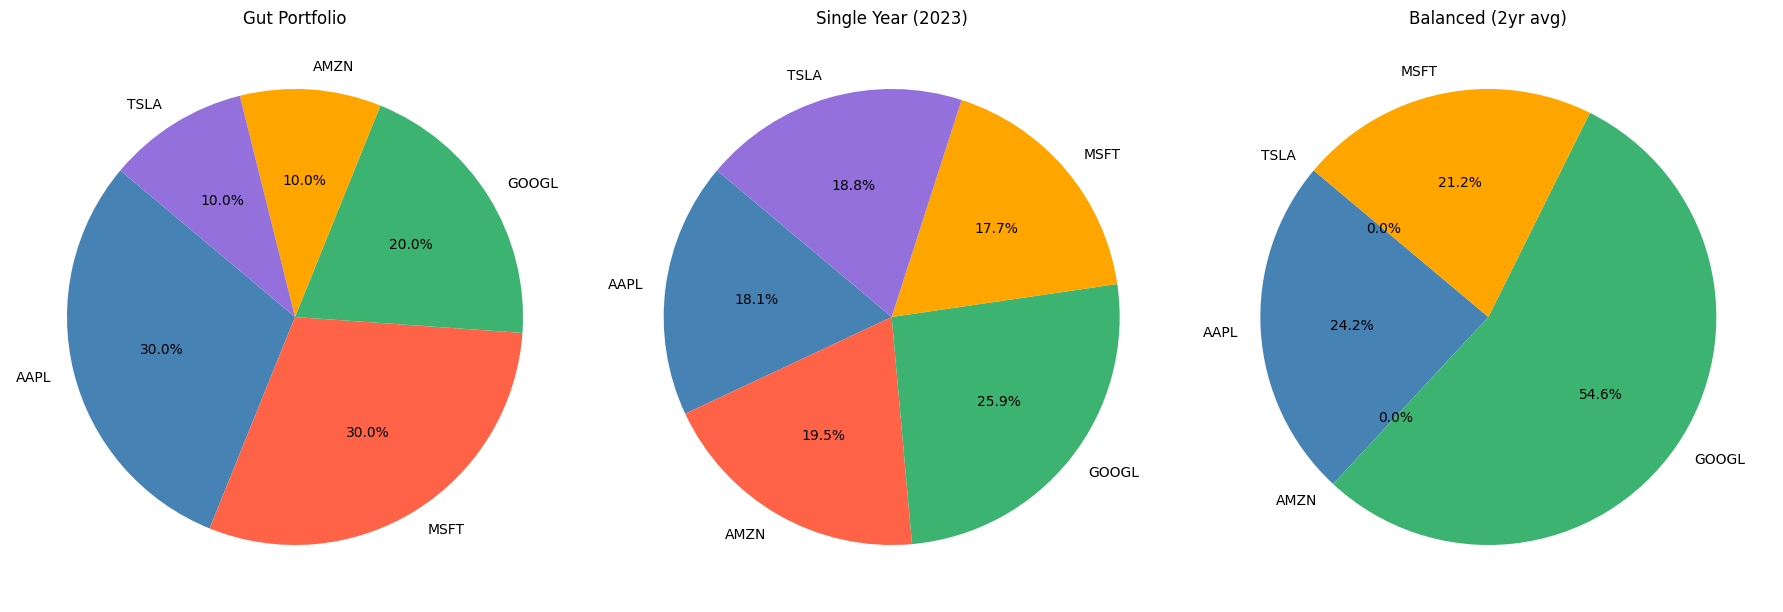

In [66]:
# Visualizing all three allocations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['steelblue','tomato','mediumseagreen','orange','mediumpurple']

portfolios = [
    (weights_series, 'Gut Portfolio'),
    (sharpe_weights, 'Single Year (2023)'),
    (balanced_weights, 'Balanced (2yr avg)')
]

for ax, (w, title) in zip(axes, portfolios):
    ax.pie(w, labels=w.index, autopct='%1.1f%%', startangle=140, colors=colors)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### What I Just Learned
built three versions of a real portfolio and compared them honestly:


Portfolio vs What it represents

---

- Gut Portfolio -> How beginners
invest - feeling based

---

- Single Year -> Data-driven but overfit to one period

---

- Balanced 2yr -> More robust - accounts for good and bad years

---


🏆 Checkpoint - what i have achieved


---


What I Did   vs   What It's Called Professionally


---


- Cleaned messy company data...*Data wrangling
- Pulled live market prices...*Financial data engineering
- Measured price swings...*Volatility analysis
- Scored stocks fairly...*Sharpe Ratio analysis
- Split money across stocks...*Portfolio allocation
- Tested across multiple years...*Backtesting
- Chose the most honest model...*Risk-adjusted decision making


### Diversification
**Correlation** - why owning Google AND Microsoft might be the same bet.

If Google drops 10% on a bad tech news day, Microsoft probably drops too - because they move together. Smart portfolio manager doesn't just pick strong stocks. They pick stocks that don't move together so when one falls, another holds or rises.
That's called **diversification**

### Measuring how Stocks move together (Correlation)
Will add a stock from a completely different industry to our portfolio. We'll add JPMorgan (JPM) - a bank and Johnson & Johnson (JNJ) - healthcare.

**The idea:** tech stocks tend to fall together. Adding different industries should protect the portfolio.

In [67]:
# Expand our ticker list
tickers_new = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'JNJ']

# Pulling 4 years of data
data_new = yf.download(tickers_new, start='2022-01-01', end='2026-01-01')['Close']
returns_new = data_new.pct_change().dropna()

print(data_new.head())
print(f"\nShape: {data_new.shape}")

/tmp/ipykernel_9209/4066074563.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_new = yf.download(tickers_new, start='2022-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  7 of 7 completed

Ticker            AAPL        AMZN       GOOGL         JNJ         JPM  \
Date                                                                     
2022-01-03  177.939743  170.404495  143.802979  151.770050  144.191574   
2022-01-04  175.681396  167.522003  143.215836  151.363052  149.657822   
2022-01-05  171.008255  164.356995  136.645630  152.371658  146.921783   
2022-01-06  168.153580  163.253998  136.618347  151.849655  148.482712   
2022-01-07  168.319778  162.554001  135.893829  153.902267  149.953873   

Ticker            MSFT        TSLA  
Date                                
2022-01-03  323.160767  399.926666  
2022-01-04  317.619507  383.196655  
2022-01-05  305.426758  362.706665  
2022-01-06  303.013336  354.899994  
2022-01-07  303.167786  342.320007  

Shape: (1003, 7)


In [68]:
#  Building The Correlation Matrix
# Calculating correlation between all stocks
correlation = returns_new.corr()

print("Correlation Matrix:")
print(correlation.round(2))

Correlation Matrix:
Ticker  AAPL  AMZN  GOOGL   JNJ   JPM  MSFT  TSLA
Ticker                                           
AAPL    1.00  0.56   0.58  0.15  0.40  0.63  0.51
AMZN    0.56  1.00   0.62  0.01  0.39  0.67  0.47
GOOGL   0.58  0.62   1.00  0.05  0.35  0.63  0.44
JNJ     0.15  0.01   0.05  1.00  0.22  0.05 -0.01
JPM     0.40  0.39   0.35  0.22  1.00  0.36  0.35
MSFT    0.63  0.67   0.63  0.05  0.36  1.00  0.43
TSLA    0.51  0.47   0.44 -0.01  0.35  0.43  1.00


How to read correlation:

Value vs Meaning
- 1.0 --- Move perfectly together0.
- 0 --- No relationship at all
- -1.0 --- Move in opposite directions

A good portfolio wants low or negative correlations between holdings.

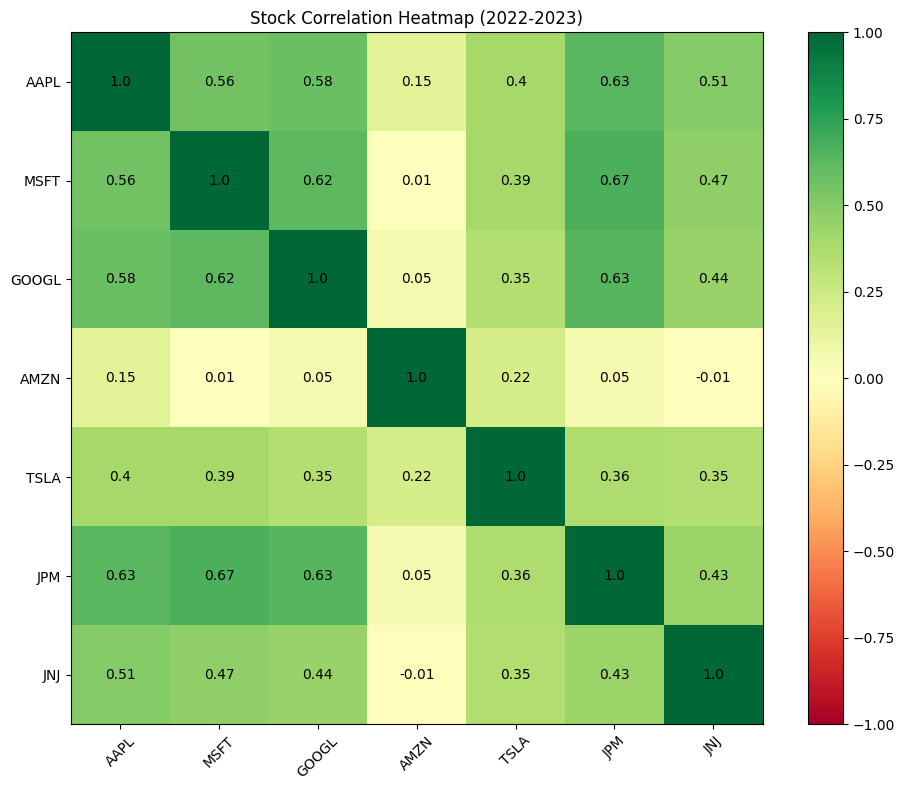

In [69]:
# Visualizing it as a Heatmap
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap manually
im = ax.imshow(correlation, cmap='RdYlGn', vmin=-1, vmax=1)

# Add colorbar
plt.colorbar(im)

# Label axes
ax.set_xticks(range(len(tickers_new)))
ax.set_yticks(range(len(tickers_new)))
ax.set_xticklabels(tickers_new, rotation=45)
ax.set_yticklabels(tickers_new)

# Add correlation numbers inside each cell
for i in range(len(tickers_new)):
    for j in range(len(tickers_new)):
        text = ax.text(j, i, round(correlation.iloc[i, j], 2),
                      ha='center', va='center', fontsize=10,
                      color='black')

plt.title('Stock Correlation Heatmap (2022-2023)')
plt.tight_layout()
plt.show()

In [70]:
# Interpretion of the Heatmap
# Finding the highest correlated pairs (excluding self-correlation of 1.0)
corr_pairs = correlation.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self correlation
corr_pairs = corr_pairs.drop_duplicates()

print("Most Correlated Pairs (move TOGETHER - bad for diversification):")
print(corr_pairs.sort_values(ascending=False).head(5).round(3))

print("\nLeast Correlated Pairs (move INDEPENDENTLY - good for diversification):")
print(corr_pairs.sort_values(ascending=True).head(5).round(3))

Most Correlated Pairs (move TOGETHER - bad for diversification):
Ticker  Ticker
AMZN    MSFT      0.668
GOOGL   MSFT      0.633
AAPL    MSFT      0.628
AMZN    GOOGL     0.625
AAPL    GOOGL     0.585
dtype: float64

Least Correlated Pairs (move INDEPENDENTLY - good for diversification):
Ticker  Ticker
JNJ     TSLA     -0.008
AMZN    JNJ       0.013
JNJ     MSFT      0.055
GOOGL   JNJ       0.055
AAPL    JNJ       0.154
dtype: float64


#### Prove Diversification Works

In [71]:
# Compare: all-tech portfolio vs diversified portfolio
tech_weights = pd.Series({
    'AAPL': 0.25, 'MSFT': 0.25, 'GOOGL': 0.25,
    'AMZN': 0.25, 'TSLA': 0.00, 'JPM': 0.00, 'JNJ': 0.00
})

diversified_weights = pd.Series({
    'AAPL': 0.20, 'MSFT': 0.20, 'GOOGL': 0.15,
    'AMZN': 0.10, 'TSLA': 0.05, 'JPM': 0.20, 'JNJ': 0.10
})

# Calculate returns and volatility for both
annual_return_new = returns_new.mean() * 252
volatility_new = returns_new.std() * (252 ** 0.5)

tech_return = (annual_return_new * tech_weights).sum()
tech_vol = (volatility_new * tech_weights).sum()
tech_sharpe = (tech_return - 0.05) / tech_vol

div_return = (annual_return_new * diversified_weights).sum()
div_vol = (volatility_new * diversified_weights).sum()
div_sharpe = (div_return - 0.05) / div_vol

# Final comparison
diversification_comparison = pd.DataFrame({
    'All-Tech Portfolio': [tech_return, tech_vol, tech_sharpe],
    'Diversified Portfolio': [div_return, div_vol, div_sharpe]
}, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])

print(diversification_comparison.round(3))

               All-Tech Portfolio  Diversified Portfolio
Annual Return               0.169                  0.175
Volatility                  0.313                  0.295
Sharpe Ratio                0.381                  0.423


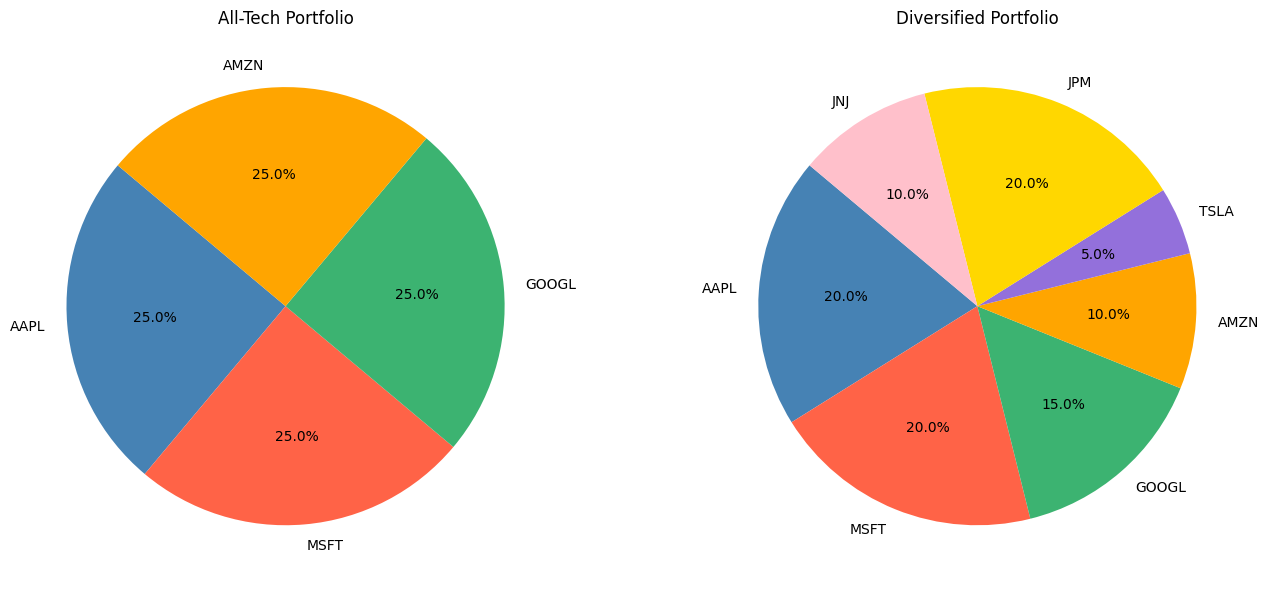

In [72]:
# Visualizing both allocations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['steelblue','tomato','mediumseagreen','orange','mediumpurple','gold','pink']

for ax, (weights, title) in zip(axes, [
    (tech_weights[tech_weights > 0], 'All-Tech Portfolio'),
    (diversified_weights[diversified_weights > 0], 'Diversified Portfolio')
]):
    ax.pie(weights, labels=weights.index, autopct='%1.1f%%',
           startangle=140, colors=colors)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### Questions
- Which two stocks are most correlated - and does that surprise you?

amazon and microsoft.....no,beacause they all belong to the tech industry

- Which pair is least correlated - what does that tell you?

Johnson & Johnson and Tesla......stocks from different industry tend to perform/move a bit different

- Did diversification improve the Sharpe Ratio vs the all-tech portfolio?

yes....it improved it from 0.381 to 0.423

- Based on the heatmap - which stock looks like the best diversifier?

Johnson & Johnson

🧠 Proved with Real Data that;

Insight vs Professional Term


---


- Tech stocks move together....*Sector correlation
- JNJ & TSLA move differently....*Low cross-sector correlation
- Diversification improved Sharpe....*Risk-adjusted optimization
- JNJ is the best diversifier....*Defensive asset

JNJ being a defensive asset is a real finance concept. Healthcare stocks hold their value during market downturns because people still need medicine regardless of the economy. That's exactly why wealth managers add them to client portfolios.

###🏆 Full Checkpoint  What I've Built so far

Project: Portfolio Analysis Engine


---


✅ Data cleaning & wrangling

✅ Live market data extraction

✅ Volatility analysis

✅ Sharpe Ratio scoring

✅ Portfolio allocation

✅ Backtesting across multiple years

✅ Correlation analysis

✅ Heatmap visualization

✅ Diversification proof



---

